BLEU (German)

=== BLEU DE Summary ===
      count     mean       std       min      25%      50%      75%        max
BLEU    2.0  7.69708  4.990393  4.168339  5.93271  7.69708  9.46145  11.225821

ROUGE (German)

=== ROUGE DE Summary ===
           count      mean       std       min       25%       50%       75%  \
ROUGE-1_f    2.0  0.285732  0.053454  0.247934  0.266833  0.285732  0.304631   
ROUGE-2_f    2.0  0.196998  0.159756  0.084034  0.140516  0.196998  0.253481   
ROUGE-L_f    2.0  0.250836  0.097605  0.181818  0.216327  0.250836  0.285344   

                max  
ROUGE-1_f  0.323529  
ROUGE-2_f  0.309963  
ROUGE-L_f  0.319853  

Bert Score Scores (German)

=== Bert Score DE Summary ===
              count      mean       std       min       25%       50%  \
BERTScore_F1    2.0  0.711344  0.058011  0.670324  0.690834  0.711344   

                   75%       max  
BERTScore_F1  0.731853  0.752363  

LLM Judge Similarity Scores (German)

=== LLM Judge DE Summary ===
        

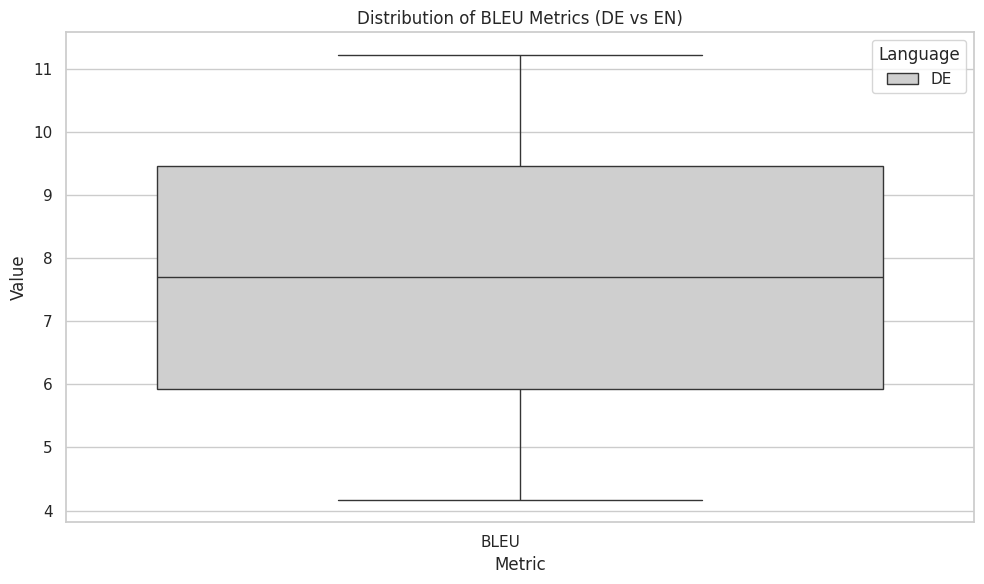

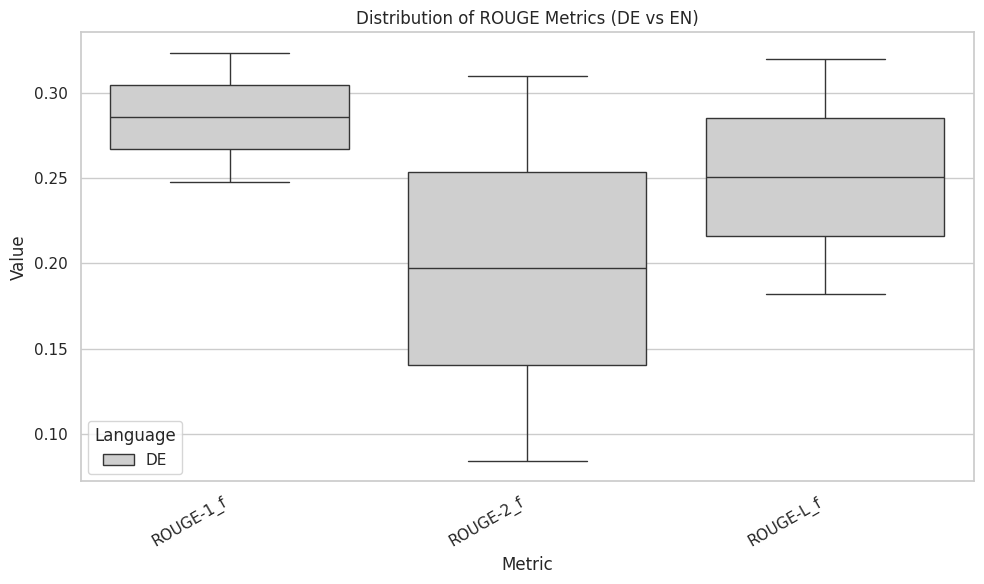

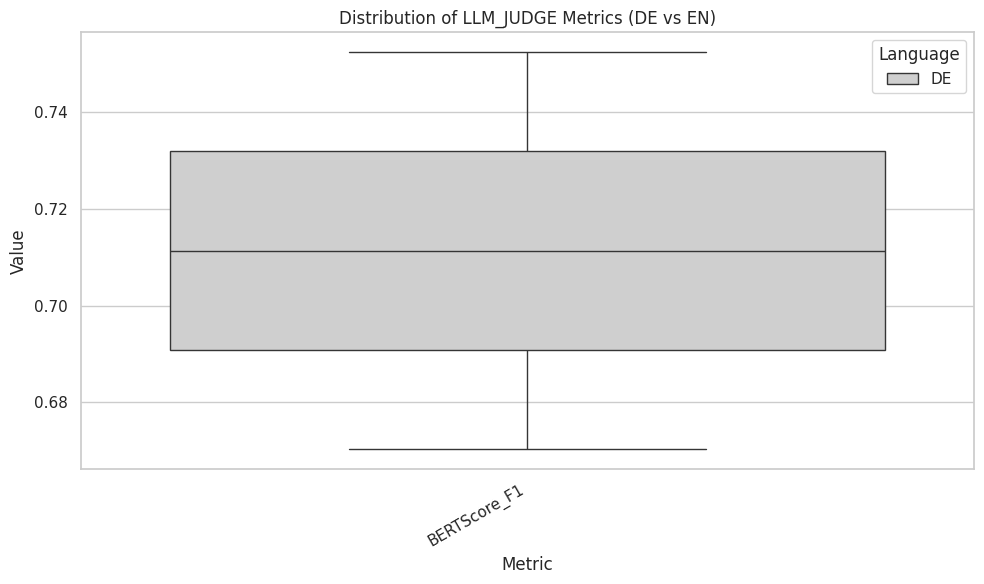

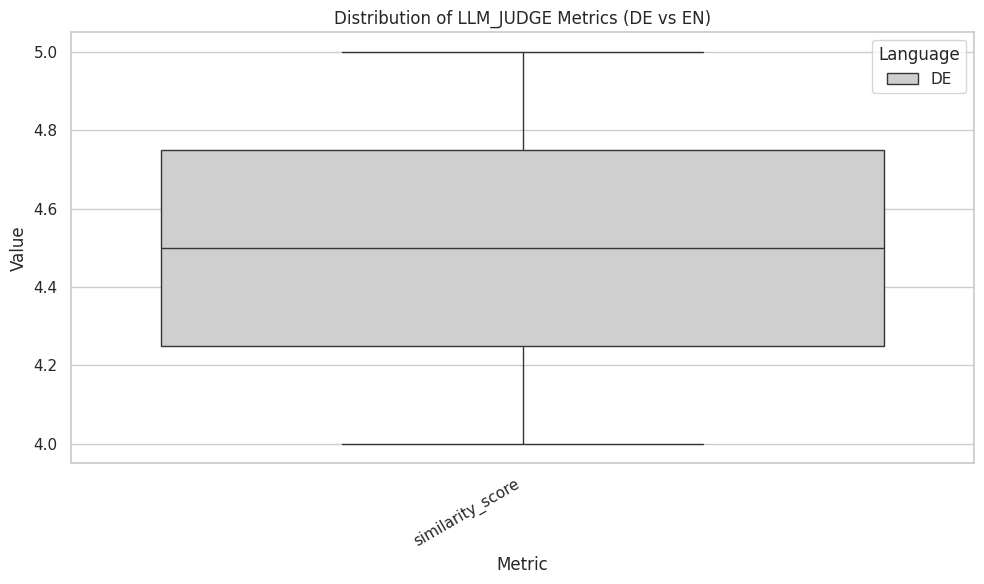

In [ ]:
# This code was adapted from https://github.com/MarvinIRW/Assessing-Answer-Accuracy-Hallucination-and-Document-Relevance-in-virtUOS-Chatbot/tree/main/code/eval

import json
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline

# ----------------------------------------------------------------------------
# 1) LOAD  BLEU, ROUGE, LLM JUDGE AND BERT SCORE
# ----------------------------------------------------------------------------

# Paths to BLEU/ROUGE CSVs (adjust to your file locations)
# /app/eval/automatic_eval
cwd = os.getcwd()
parent = os.path.abspath(os.path.join(cwd, os.pardir))  
paths = os.path.join(parent, "result_paths.json")

with open(paths, "r") as f:
    result_paths = json.load(f)

bleu_de_path = result_paths["output_csv_bleu"]
#bleu_en_path = "../../../data/eval/bleu_evaluation_en.csv"
rouge_de_path = result_paths["output_csv_rouge"]
#rouge_en_path = "../../../data/eval/rouge_evaluation_en.csv"

# Read the CSVs
bleu_de = pd.read_csv(bleu_de_path)
#bleu_en = pd.read_csv(bleu_en_path)
rouge_de = pd.read_csv(rouge_de_path)
#rouge_en = pd.read_csv(rouge_en_path)

bert_score_df_de = pd.read_csv(result_paths["output_csv_bert"])
llm_judge_df = pd.read_csv(result_paths["csv_path_de"])

# Columns of interest
bleu_cols = [
    "BLEU",
]
rouge_cols = [
    "ROUGE-1_f","ROUGE-2_f",
    "ROUGE-L_f",
]

bert_score_cols = ["BERTScore_F1"]

llm_judge_cols = [
    "similarity_score"]

# --- Compute summary stats for BLEU and ROUGE  ---
def summarize_metrics(df, metric_cols, lang_label):
    summary_df = df[metric_cols].describe().transpose()  # mean, std, min, max, etc.
    print(f"\n=== {lang_label} Summary ===")
    print(summary_df)
    return summary_df

print("BLEU (German)")
bleu_de_summary = summarize_metrics(bleu_de, bleu_cols, lang_label="BLEU DE")

#print("\nBLEU (English)")
#bleu_en_summary = summarize_metrics(bleu_en, bleu_cols, lang_label="BLEU EN")

print("\nROUGE (German)")
rouge_de_summary = summarize_metrics(rouge_de, rouge_cols, lang_label="ROUGE DE")

#print("\nROUGE (English)")
#rouge_en_summary = summarize_metrics(rouge_en, rouge_cols, lang_label="ROUGE EN")

print("\nBert Score Scores (German)")
llm_judge_summary = summarize_metrics(bert_score_df_de, bert_score_cols, lang_label="Bert Score DE")



print("\nLLM Judge Similarity Scores (German)")
llm_judge_summary = summarize_metrics(llm_judge_df, llm_judge_cols, lang_label="LLM Judge DE")

# ----------------------------------------------------------------------------
# 2) OPTIONAL: DISTRIBUTION PLOTS (EXAMPLE: BOX PLOTS)
# ----------------------------------------------------------------------------

sns.set_theme(style="whitegrid")
palette = {'DE': '#cfcfcf', 'EN': '#ac0634'}


# Merge the data into a single DF for easy plotting: 
# add a 'Language' column and a 'Metric' column
bleu_de_long = bleu_de.melt(
    id_vars=["question_id_q"],
    value_vars=bleu_cols,
    var_name="Metric",
    value_name="Value"
)
bleu_de_long["Language"] = "DE"

plt.figure(figsize=(10,6))
sns.boxplot(data=bleu_de_long, x="Metric", y="Value", hue="Language", palette=palette)
plt.title("Distribution of BLEU Metrics (DE vs EN)")
plt.xticks(ha="right")
plt.tight_layout()
plt.show()

# bleu_en_long = bleu_en.melt(
#     id_vars=["question_id_q"],
#     value_vars=bleu_cols,
#     var_name="Metric",
#     value_name="Value"
# )
#bleu_en_long["Language"] = "EN"

#bleu_concat = pd.concat([bleu_de_long, bleu_en_long], ignore_index=True)

# plt.figure(figsize=(10,6))
# sns.boxplot(data=bleu_concat, x="Metric", y="Value", hue="Language", palette=palette)
# plt.title("Distribution of BLEU Metrics (DE vs EN)")
# plt.xticks(ha="right")
# plt.tight_layout()
# plt.show()



# Similarly for ROUGE:
rouge_de_long = rouge_de.melt(
    id_vars=["question_id_q"],
    value_vars=rouge_cols,
    var_name="Metric",
    value_name="Value",
)
rouge_de_long["Language"] = "DE"

plt.figure(figsize=(10,6))
sns.boxplot(data=rouge_de_long, x="Metric", y="Value", hue="Language", palette=palette)
plt.title("Distribution of ROUGE Metrics (DE vs EN)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# rouge_en_long = rouge_en.melt(
#     id_vars=["question_id_q"],
#     value_vars=rouge_cols,
#     var_name="Metric",
#     value_name="Value"
# )
# rouge_en_long["Language"] = "EN"

# rouge_concat = pd.concat([rouge_de_long, rouge_en_long], ignore_index=True)

# plt.figure(figsize=(10,6))
# sns.boxplot(data=rouge_concat, x="Metric", y="Value", hue="Language", palette=palette)
# plt.title("Distribution of ROUGE Metrics (DE vs EN)")
# plt.xticks(rotation=30, ha="right")
# plt.tight_layout()
# plt.show()

# Bert Score:
bert_score_de_long = bert_score_df_de.melt(
    id_vars=["question_id_q"],
    value_vars=bert_score_cols,
    var_name="Metric",
    value_name="Value",
)
bert_score_de_long["Language"] = "DE"

plt.figure(figsize=(10,6))
sns.boxplot(data=bert_score_de_long, x="Metric", y="Value", hue="Language", palette=palette)
plt.title("Distribution of Bert Score Metric (DE vs EN)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()



# Similarly for LLM Judges:
llm_judge_de_long = llm_judge_df.melt(
    id_vars=["question_id_q"],
    value_vars=llm_judge_cols,
    var_name="Metric",
    value_name="Value",
)
llm_judge_de_long["Language"] = "DE"

plt.figure(figsize=(10,6))
sns.boxplot(data=llm_judge_de_long, x="Metric", y="Value", hue="Language", palette=palette)
plt.title("Distribution of LLM_JUDGE Metrics (DE vs EN)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()